In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# # Download data and make Dataframe

In [2]:
load_data = yf.download('GOOGL', start="2024-01-23", end="2025-01-23")
df = pd.DataFrame(load_data)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2024-01-23,145.747620,145.886389,144.221162,144.607733,21636100
2024-01-24,147.393036,148.532937,146.798319,147.234439,25233500
2024-01-25,150.535156,151.704793,148.225634,148.750989,29149100
2024-01-26,150.852356,151.199271,149.682719,149.771940,26115500
2024-01-29,152.160736,152.428367,150.099016,150.723484,27784300


# # Data exploratory

In [3]:
df.head()
df.isna().sum()
df.info()
df.describe()


<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2024-01-23 to 2025-01-22
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   251 non-null    float64
 1   (High, GOOGL)    251 non-null    float64
 2   (Low, GOOGL)     251 non-null    float64
 3   (Open, GOOGL)    251 non-null    float64
 4   (Volume, GOOGL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,165.401485,167.092365,163.732252,165.349359,2.742684e+07
std,15.764508,15.998844,15.607795,15.749121,1.132432e+07
min,130.245071,132.068934,129.521515,130.720887,1.024210e+07
25%,154.633812,155.976908,153.226305,154.377764,2.030655e+07
50%,165.155518,166.622538,163.003136,165.166478,2.415090e+07
75%,175.222603,176.569293,173.344068,175.216312,3.125470e+07
max,197.339249,201.238910,196.841878,198.035655,7.191000e+07


# # Cleaning Data

In [4]:
# remove ticker
df.columns = df.columns.droplevel(1)

# Reset index
df.reset_index(inplace=True)

# make sure column Data ia proper datetime type
df.head()

# monthly volumes
df['Month'] = df['Date'].dt.to_period("M")

# # Monthly volumes

In [5]:
monthly_volume = df.groupby("Month").Volume.sum()
months = [str(m) for m in monthly_volume.index]
volumes = monthly_volume.values

# # Calculating Moving Average
rolling(window=20) -> slides 20-days of data and calculate mean at each point

In [6]:
# moving average of 20-days
df["MA20"] = df["Close"].rolling(window=20).mean()

# moving average of 50-days
df["MA50"] = df["Close"].rolling(window=50).mean()

# # Calculating Daily return
How much % the stock gained each day?

pct_change() -> how much percentage change of previous row

In [7]:
df["Daily Return"] = round(df["Close"].pct_change() * 100, 3)

# # Analyze Data

In [8]:
# Highest price ever
df.High.max()

# Lowest price ever
df.Low.min()

# Average closing
df["Close"].mean()

# Best daily return 
df["Daily Return"].max()

# worst daily return
df["Daily Return"].min()

np.float64(-7.5)

# # Visualization

# # Closing price and moving averages

Plot line chart (Date + closing price and moving averages)

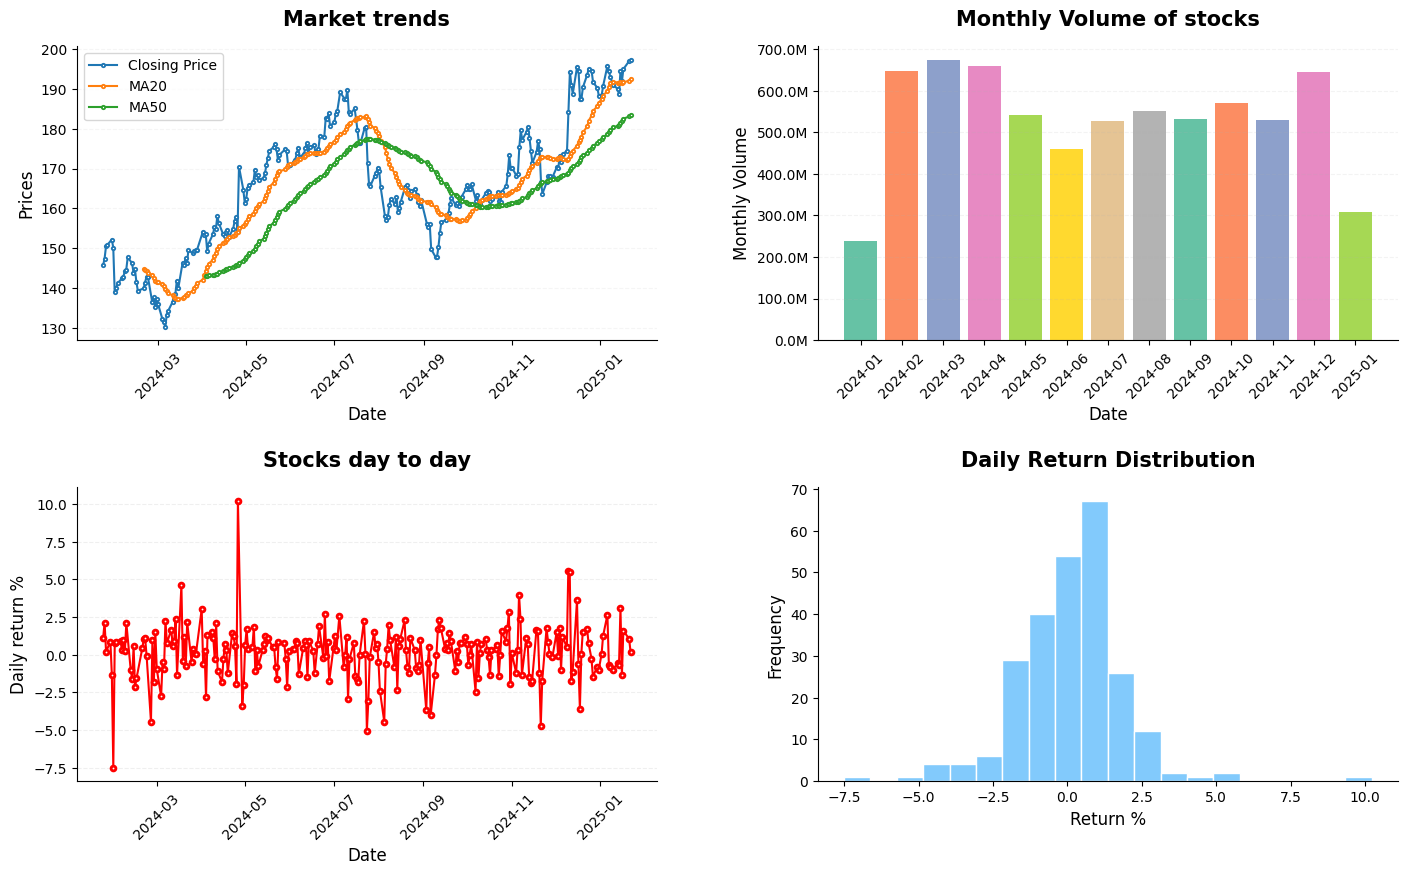

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# figure size 
plt.tight_layout(pad=8.5)

# separate axes
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]


# Line chart (Data + Closing Price and Moving Averages)
# Plot Closing Price
ax1.plot(
    df["Date"], df["Close"], marker='.',
    markersize=2.5, markerfacecolor="white",
    markeredgewidth=2.5, label="Closing Price"
)

# Plot MA20
ax1.plot(
    df["Date"], df["MA20"], marker='.',
    markersize=2.5, markerfacecolor="white",
    markeredgewidth=2.5, label="MA20"
)

# Plot MA50
ax1.plot(
    df["Date"], df["MA50"], marker='.',
    markersize=2.5, markerfacecolor="white", 
    markeredgewidth=2.5, label="MA50"
)

# add style and text
ax1.set_title("Market trends", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Prices", fontsize=12)
ax1.grid(axis="y", linestyle="--", alpha=0.12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()


# Volume bar chart
# Bar chart (Date and Volume)
colors = plt.cm.Set2.colors
ax2.bar(months, volumes, color=colors[:len(months)])

# add style and text
ax2.set_title("Monthly Volume of stocks", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Monthly Volume", fontsize=12)

ax2.spines[["top", "right"]].set_visible(False)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _ : f"{x/1e6:.0f}M")
)
ax2.grid(axis="y", linestyle="--", alpha=0.15)
# date rotation
ax2.tick_params(axis='x', rotation=45)


# Daily return line
# Line chart (Date by return)
ax3.plot(
    df['Date'], df['Daily Return'],
    color='r', marker='.', markersize=4, 
    markeredgewidth=3.5, markerfacecolor='w'
)

# add text
ax3.set_title("Stocks day to day", fontsize=15, fontweight='bold', pad=15)
ax3.set_xlabel("Date", fontsize=12, fontweight='normal')
ax3.set_ylabel("Daily return %", fontsize=12, fontweight='normal')
ax3.grid(axis='y', linestyle='--', alpha=0.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.tick_params(axis='x', rotation=45)


# plot histogram return distribution
ax4.hist(df['Daily Return'], bins=20, color='#82cafc', edgecolor='white')

# add styles and text
ax4.set_title("Daily Return Distribution", fontsize=15, fontweight='bold', pad=15)
ax4.set_xlabel("Return %", fontsize=12)
ax4.set_ylabel("Frequency", fontsize=12)
ax4.spines[['top', 'right']].set_visible(False)

# Save image
FILE_NAME = "stock.png"
plt.savefig(FILE_NAME,  dpi=150, bbox_inches='tight')
 
plt.show()